In [ ]:
from scipy.stats import randint, uniform
import sys
from pathlib import Path

# Go up one level to project root
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))
from src.utils.load_data import get_split_from_file
from src.utils.tune_hyperparameters import ModelTuner, PipelineTuner
filename = r"../../data/processed/no_cat_unknown.csv"


# model
from sklearn.ensemble import RandomForestClassifier


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

e:\dev\workspace\Apziva\Project2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
random_state = 0

# no dates

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 1/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.985, test=0.895) total time=   0.9s
[CV 2/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 2/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.987, test=0.880) total time=   0.9s
[CV 3/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 3/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67;, score=(train=0.986, test=0.872) total time=   0.9s
[CV 4/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=14, classifier__n_estimators=67
[CV 4/5; 1/100] END classifier__bootstrap=True, classifi

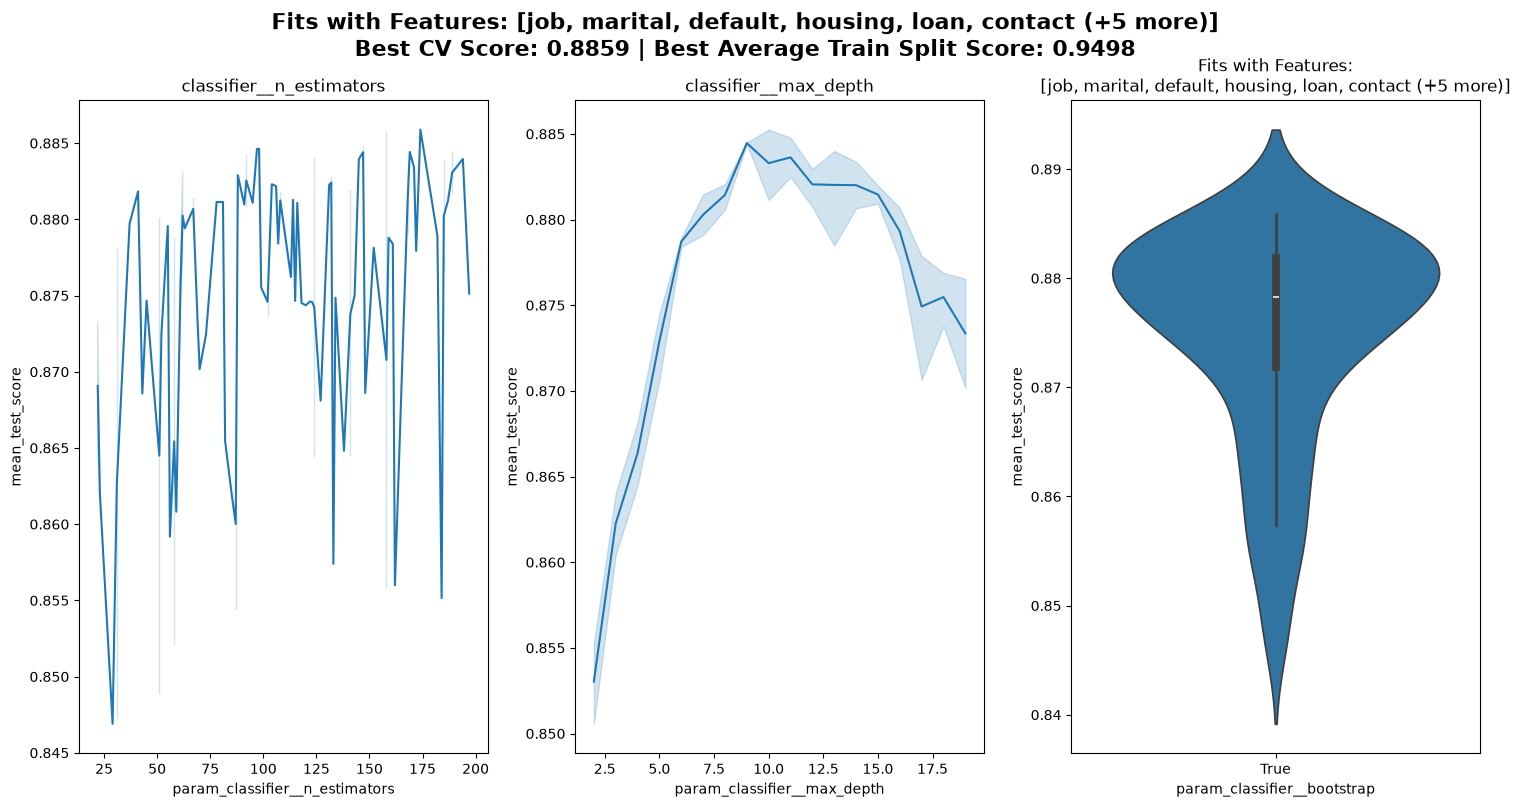



Feature Permutation Importance
______________________
duration: 0.298 +/- 0.008
housing: 0.016 +/- 0.003
campaign: 0.014 +/- 0.002
balance: 0.010 +/- 0.002
age: 0.008 +/- 0.002
loan: 0.007 +/- 0.002
education: 0.003 +/- 0.002
contact: 0.002 +/- 0.001
job: 0.002 +/- 0.002
marital: 0.002 +/- 0.002
default: -0.000 +/- 0.000

______________________



classifier:  RandomForestClassifier(max_depth=10, n_estimators=174, random_state=0) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


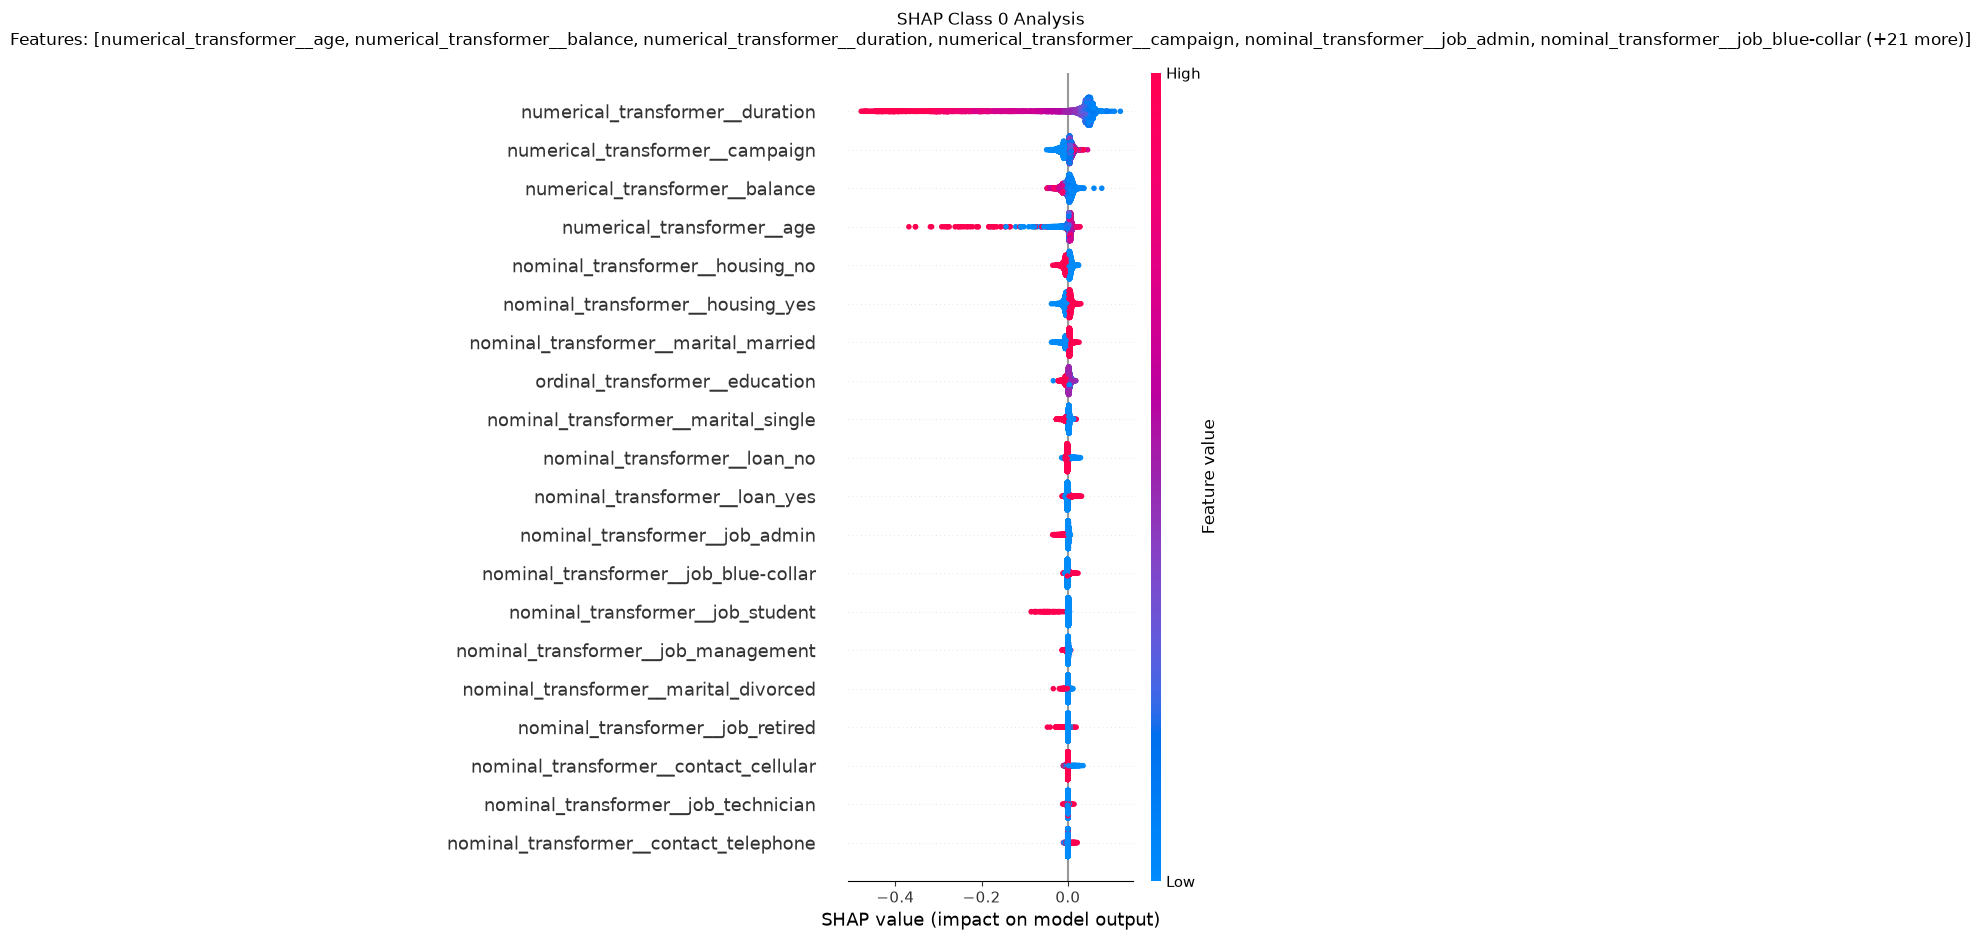

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


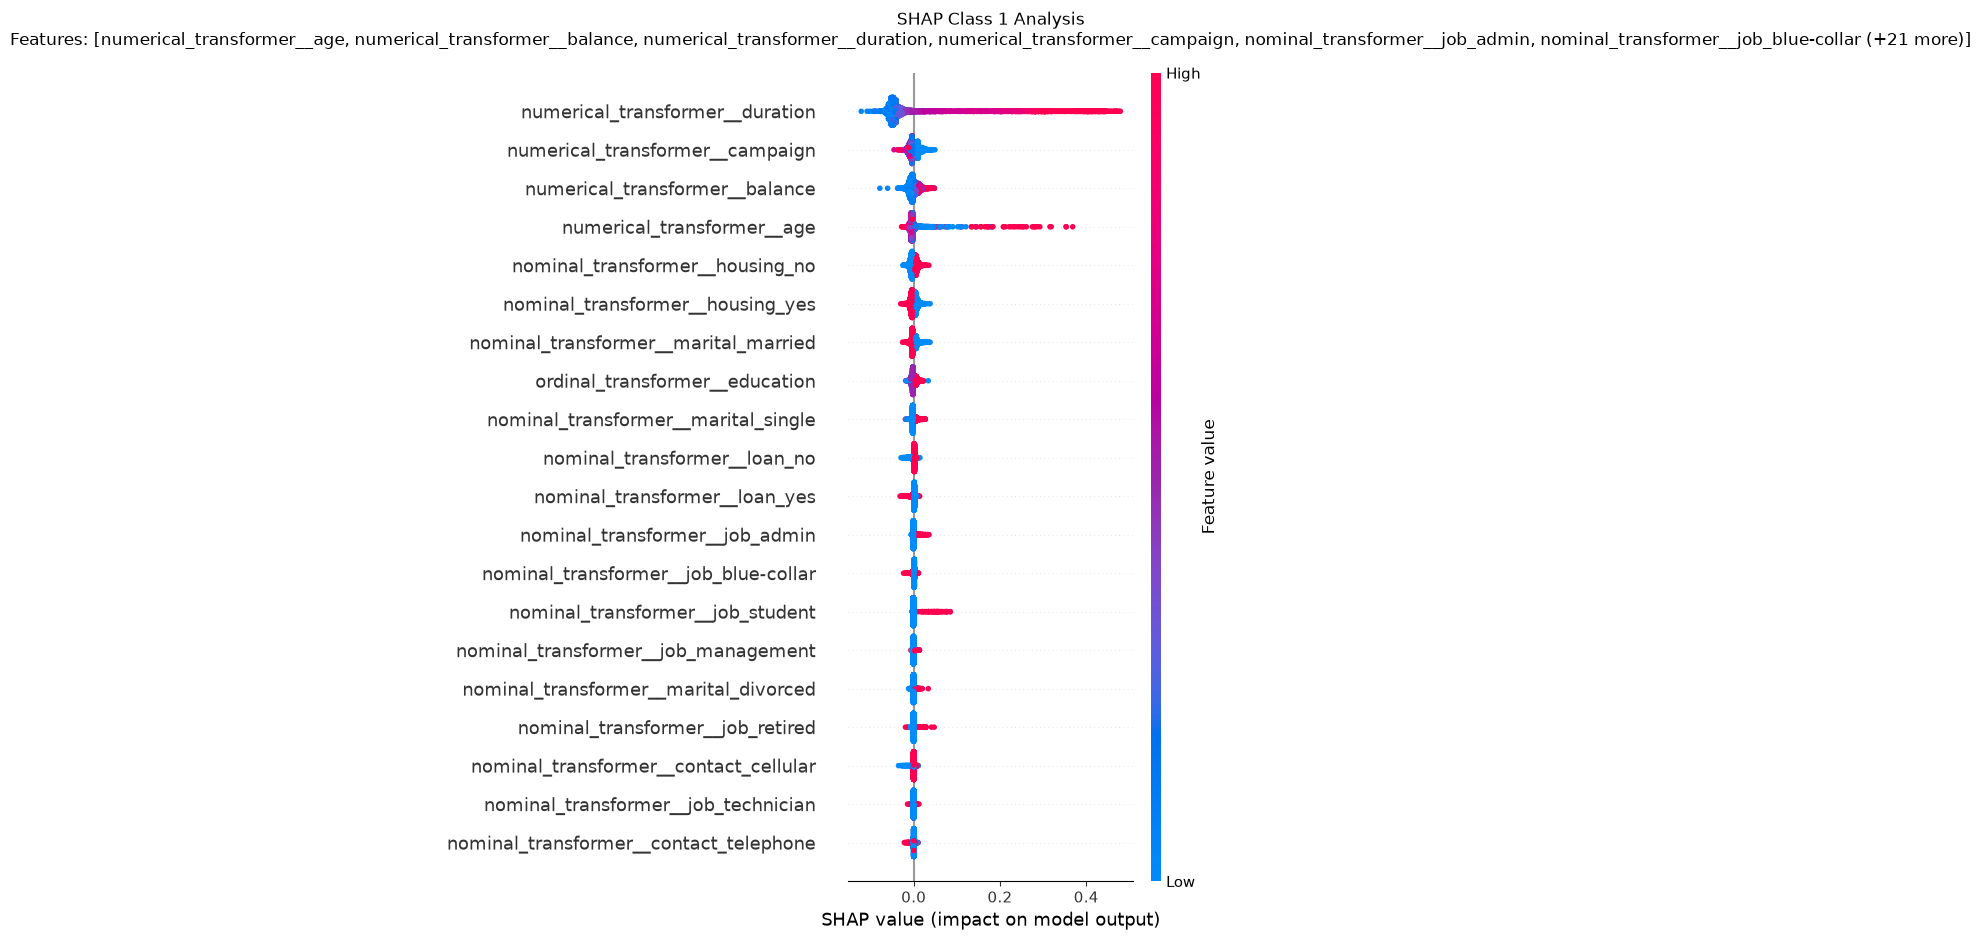

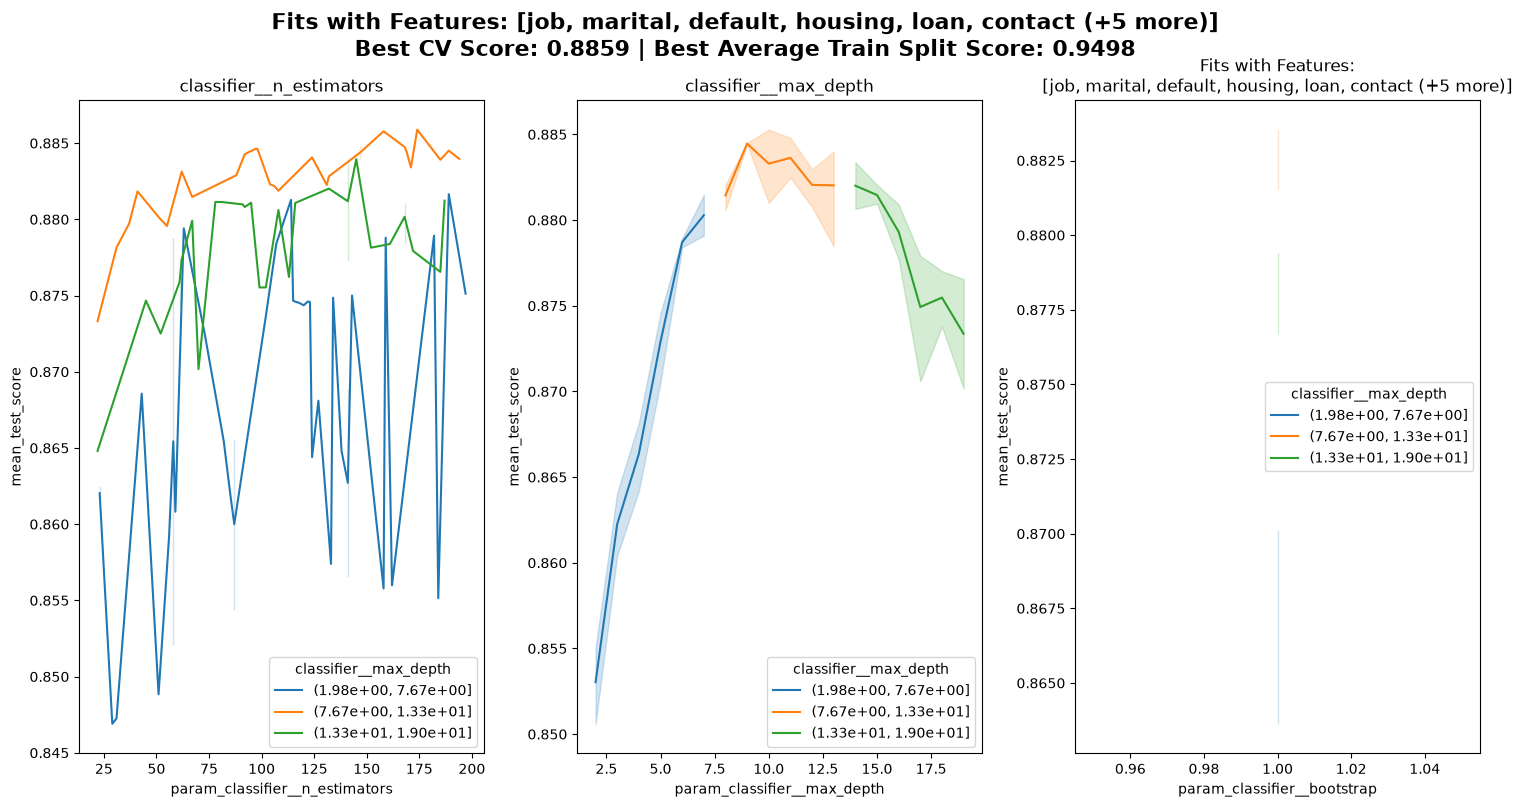

In [ ]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact',]
# nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

# numerical_features = ['age', 'balance','day', 'duration', 'campaign',]
numerical_features = ['age', 'balance', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    # "classifier__min_samples_split": randint(2, 21),
    # "classifier__min_samples_leaf": randint(1, 21),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}



split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)

search = t.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t.feature_permutation(search.best_params_, scoring = 'roc_auc')
t.shap_analysis(search.best_params_)
t.display_parameter_fits(search, parameter_grid, groupby="classifier__max_depth")

In [ ]:
t.predict_test_split(t.last_search.best_params_, scoring = ["roc_auc","accuracy"])

{'roc_auc': 0.888661717738144, 'accuracy': 0.9193763072827533}

In [ ]:
# t.save_model(filename="../../src/models/saved_models/drop_emptyData_and_dates_RandomForestClassifier", hyperparams=t.last_search.best_params_, final=True, notes="Trained with ROC_AUC, CV: 0.9378, {'roc_auc': 0.9324020467019852, 'accuracy': 0.9241300627495722}")

In [ ]:
random_state += 1

# no month

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160
[CV 1/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160;, score=(train=0.916, test=0.905) total time=   1.2s
[CV 2/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160
[CV 2/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160;, score=(train=0.920, test=0.887) total time=   1.2s
[CV 3/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160
[CV 3/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160;, score=(train=0.919, test=0.895) total time=   1.3s
[CV 4/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=7, classifier__n_estimators=160
[CV 4/5; 1/100] END classifier__bootstrap=True, classifi

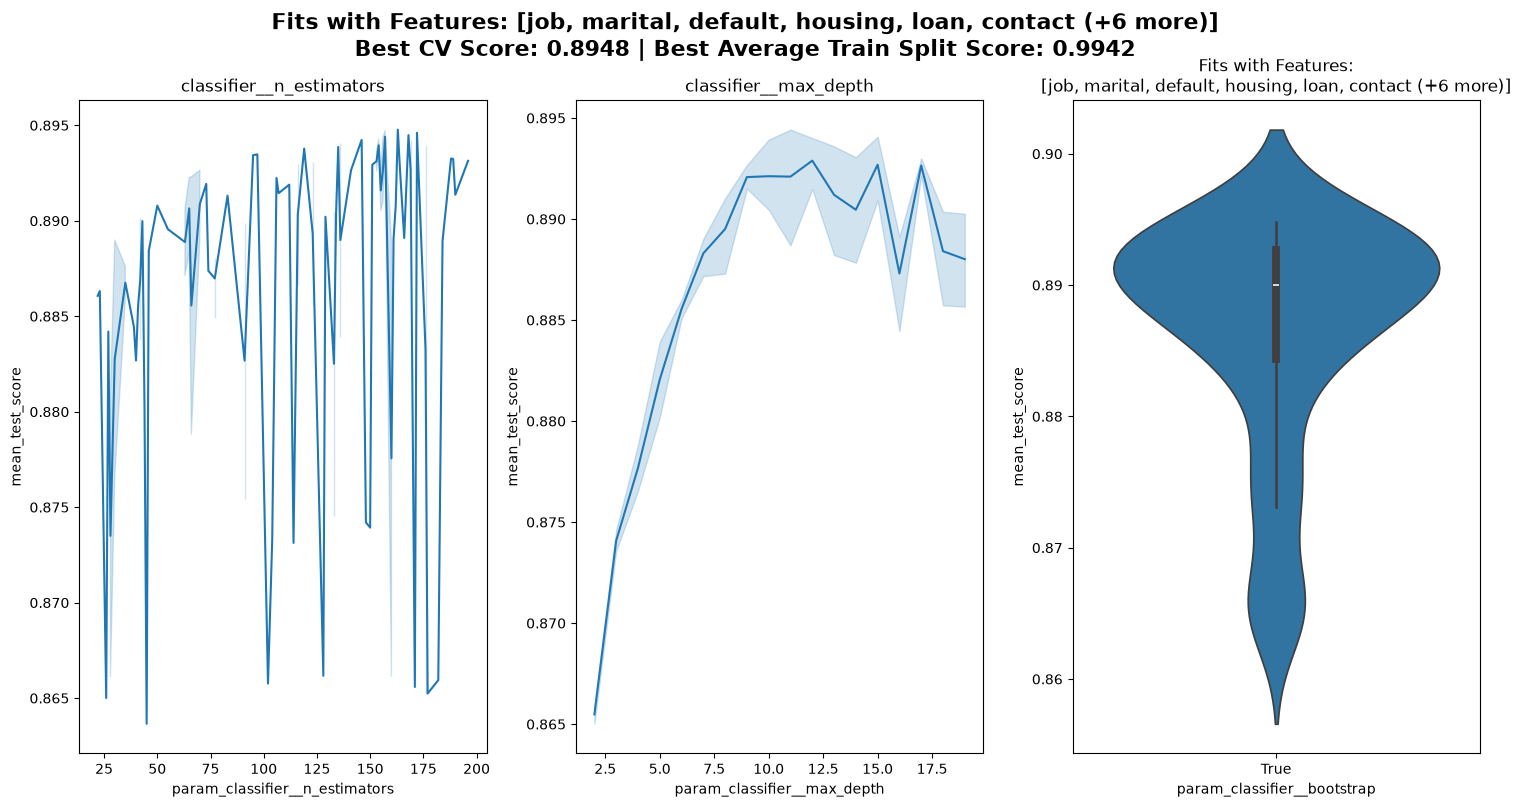



Feature Permutation Importance
______________________
duration: 0.320 +/- 0.009
day: 0.016 +/- 0.001
housing: 0.013 +/- 0.002
campaign: 0.013 +/- 0.002
balance: 0.012 +/- 0.002
age: 0.009 +/- 0.001
marital: 0.005 +/- 0.002
contact: 0.005 +/- 0.001
job: 0.003 +/- 0.002
loan: 0.003 +/- 0.002
education: 0.001 +/- 0.001
default: 0.000 +/- 0.000

______________________



classifier:  RandomForestClassifier(max_depth=15, n_estimators=163, random_state=1) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


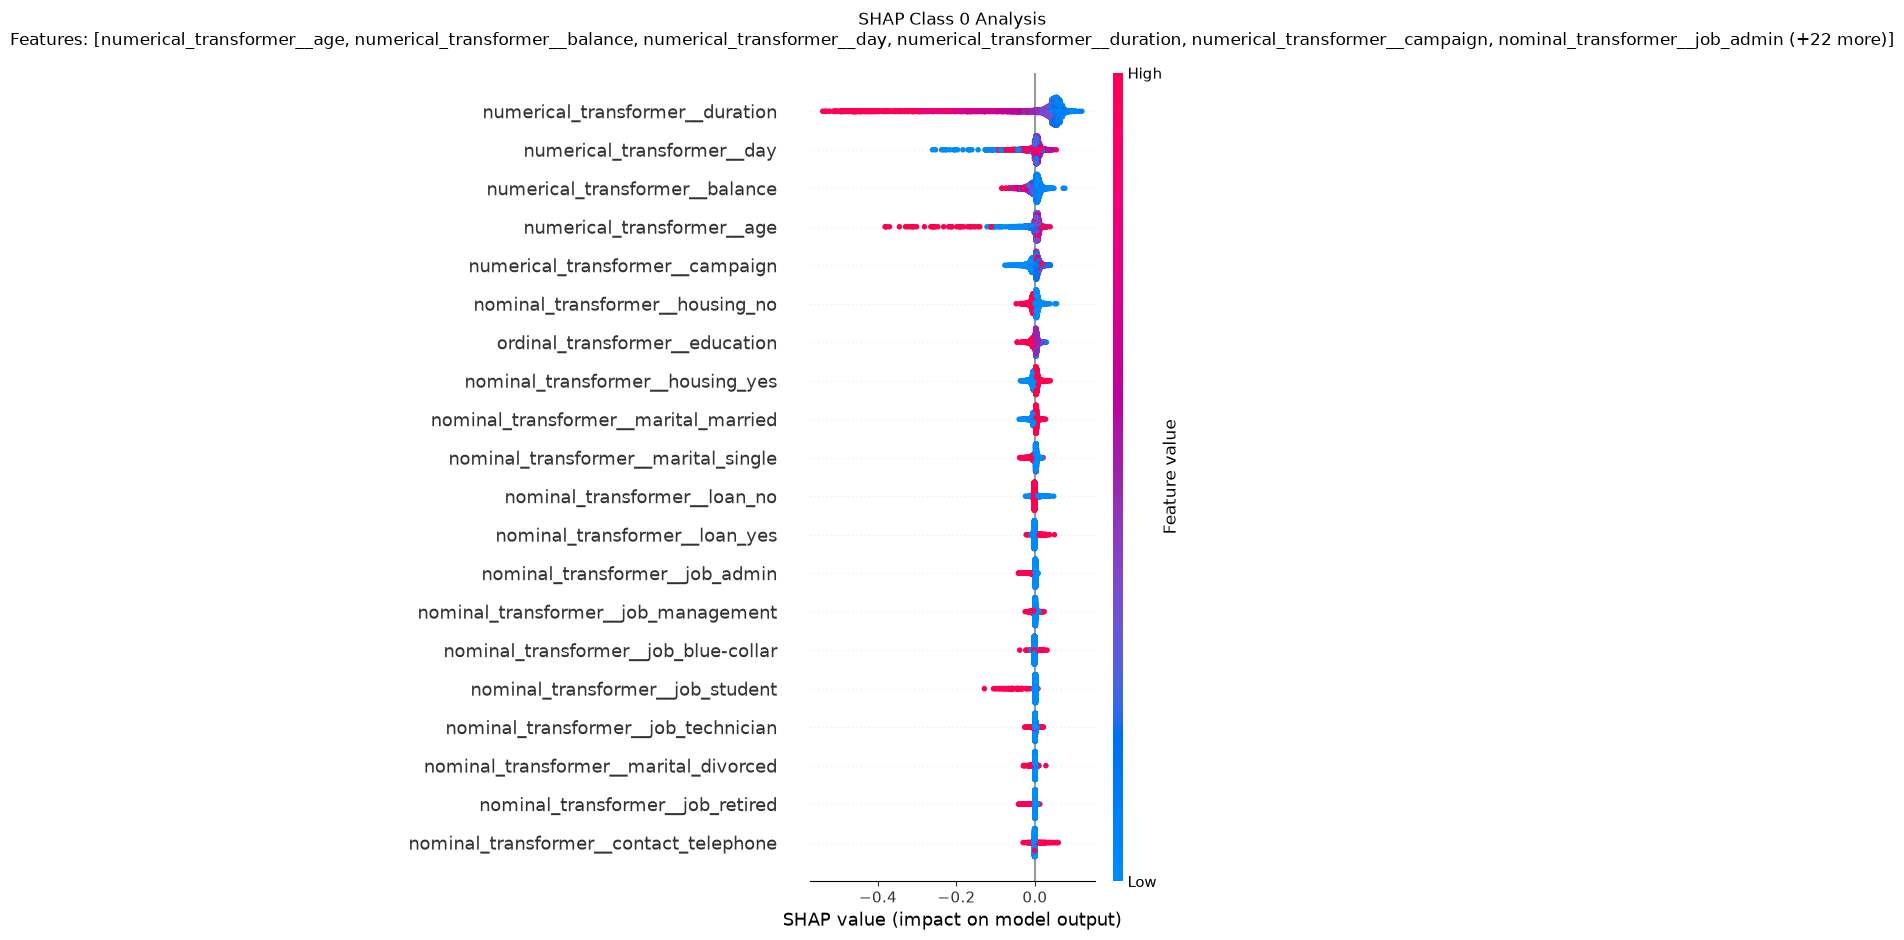

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


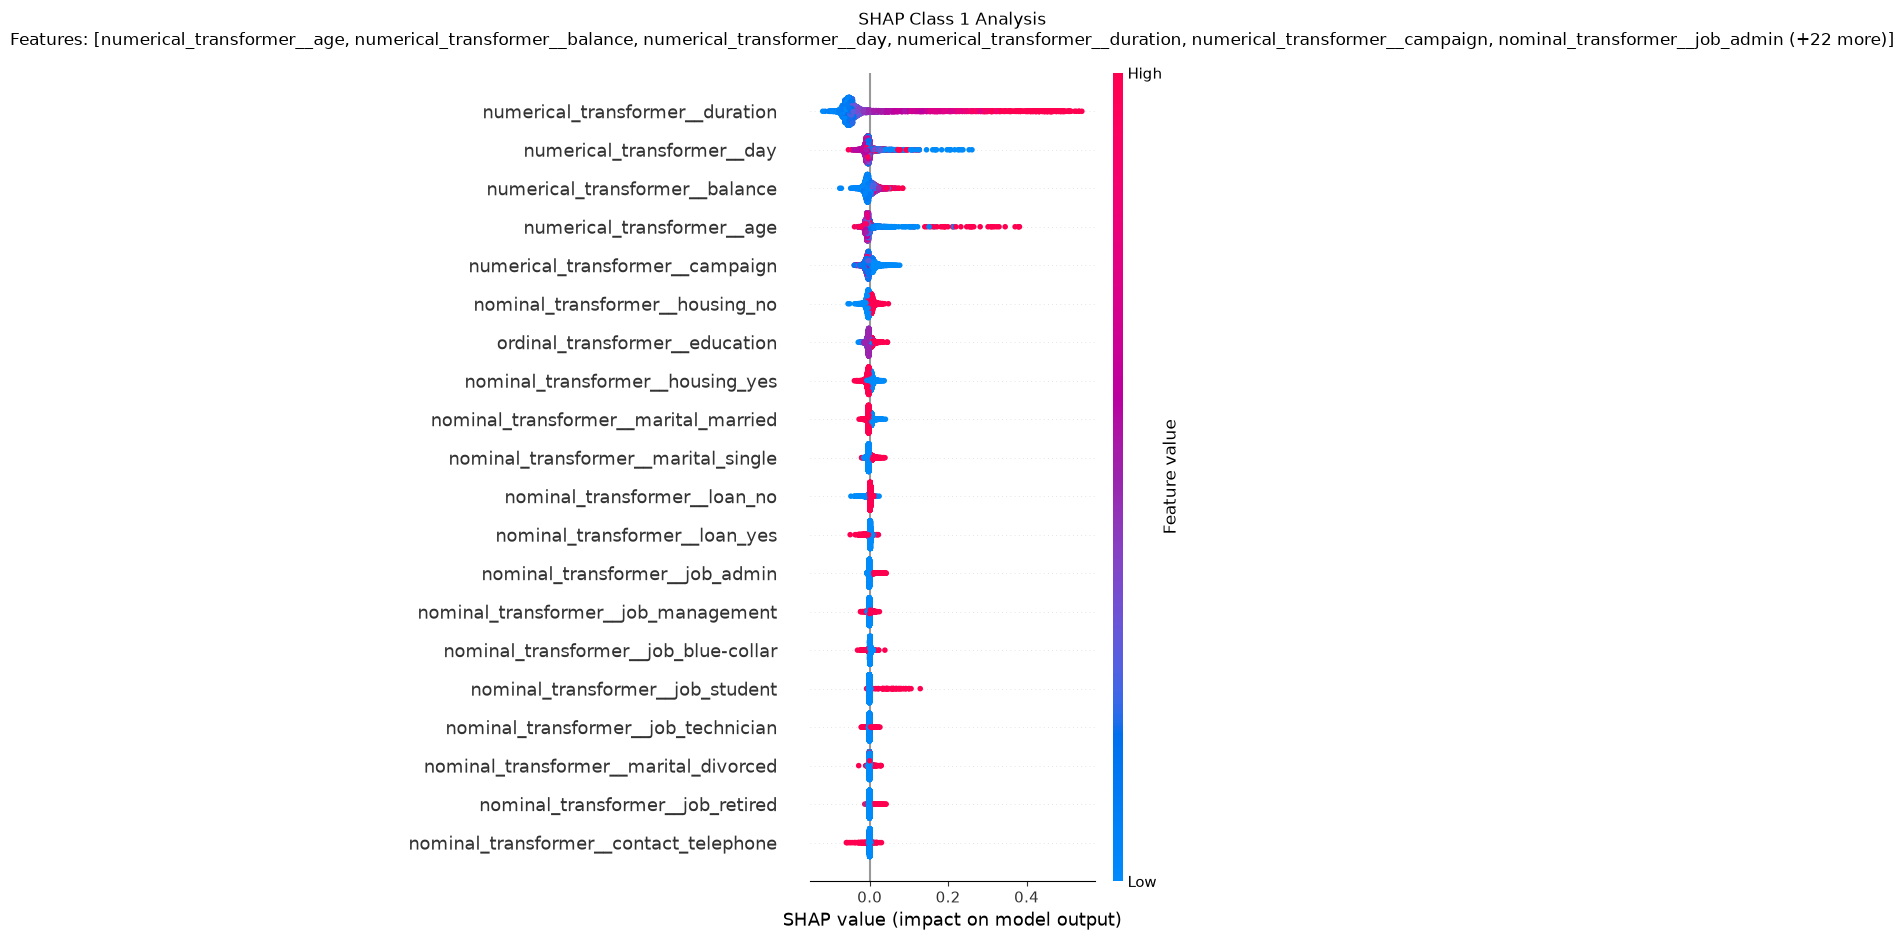

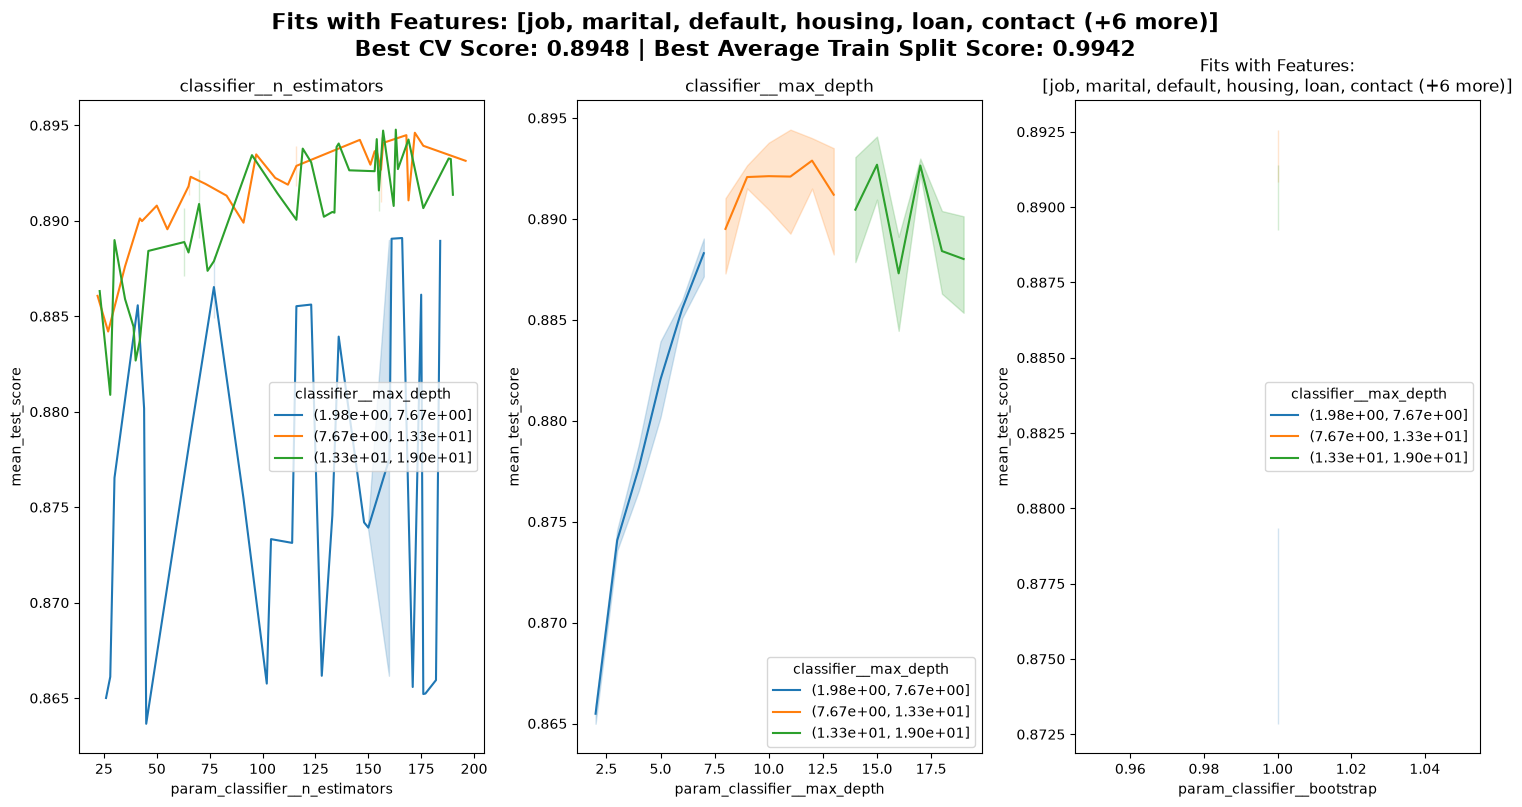

In [ ]:
# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact',]
# nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance','day', 'duration', 'campaign',]
# numerical_features = ['age', 'balance', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    # "classifier__min_samples_split": randint(2, 21),
    # "classifier__min_samples_leaf": randint(1, 21),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t1 = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)

search1 = t1.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t1.feature_permutation(search1.best_params_, scoring = 'roc_auc')
t1.shap_analysis(search1.best_params_)
t1.display_parameter_fits(search1, parameter_grid, groupby="classifier__max_depth")

In [ ]:
t1.predict_test_split(t1.last_search.best_params_, scoring = ["roc_auc","accuracy"])


{'roc_auc': 0.8986997804145643, 'accuracy': 0.9207073588134627}

# no outlier months

In [ ]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35
[CV 1/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35;, score=(train=0.973, test=0.936) total time=   0.3s
[CV 2/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35
[CV 2/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35;, score=(train=0.972, test=0.932) total time=   0.3s
[CV 3/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35
[CV 3/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35;, score=(train=0.975, test=0.927) total time=   0.2s
[CV 4/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=10, classifier__n_estimators=35
[CV 4/5; 1/100] END classifier__bootstrap=True, classifi

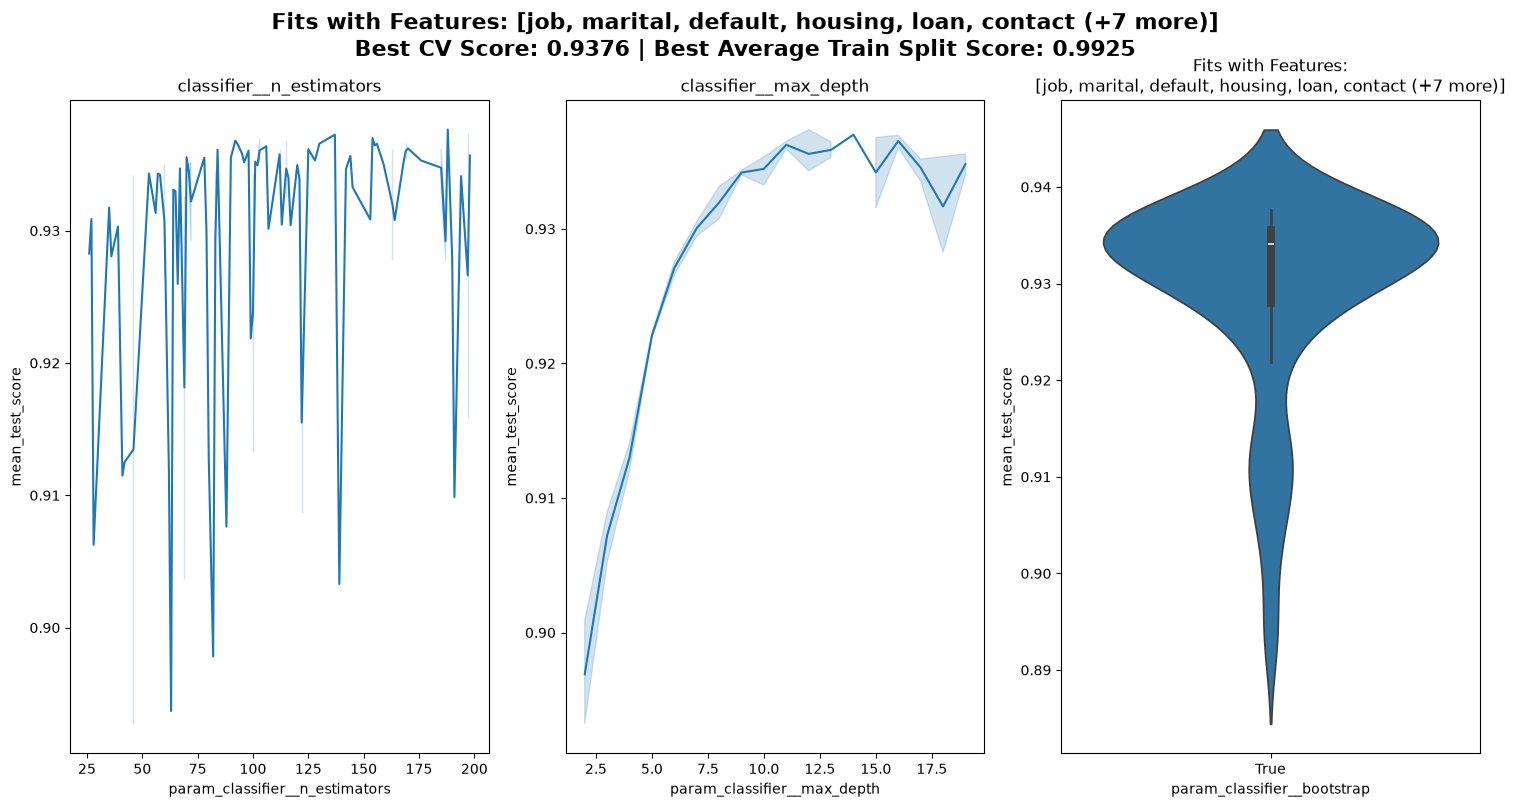



Feature Permutation Importance
______________________
duration: 0.291 +/- 0.007
month: 0.099 +/- 0.006
day: 0.022 +/- 0.002
housing: 0.013 +/- 0.001
age: 0.004 +/- 0.001
balance: 0.002 +/- 0.001
loan: 0.001 +/- 0.001
education: 0.001 +/- 0.000
campaign: 0.001 +/- 0.001
contact: 0.001 +/- 0.000
marital: 0.001 +/- 0.001
default: 0.000 +/- 0.000
job: 0.000 +/- 0.000

______________________



classifier:  RandomForestClassifier(max_depth=13, n_estimators=188, random_state=2) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


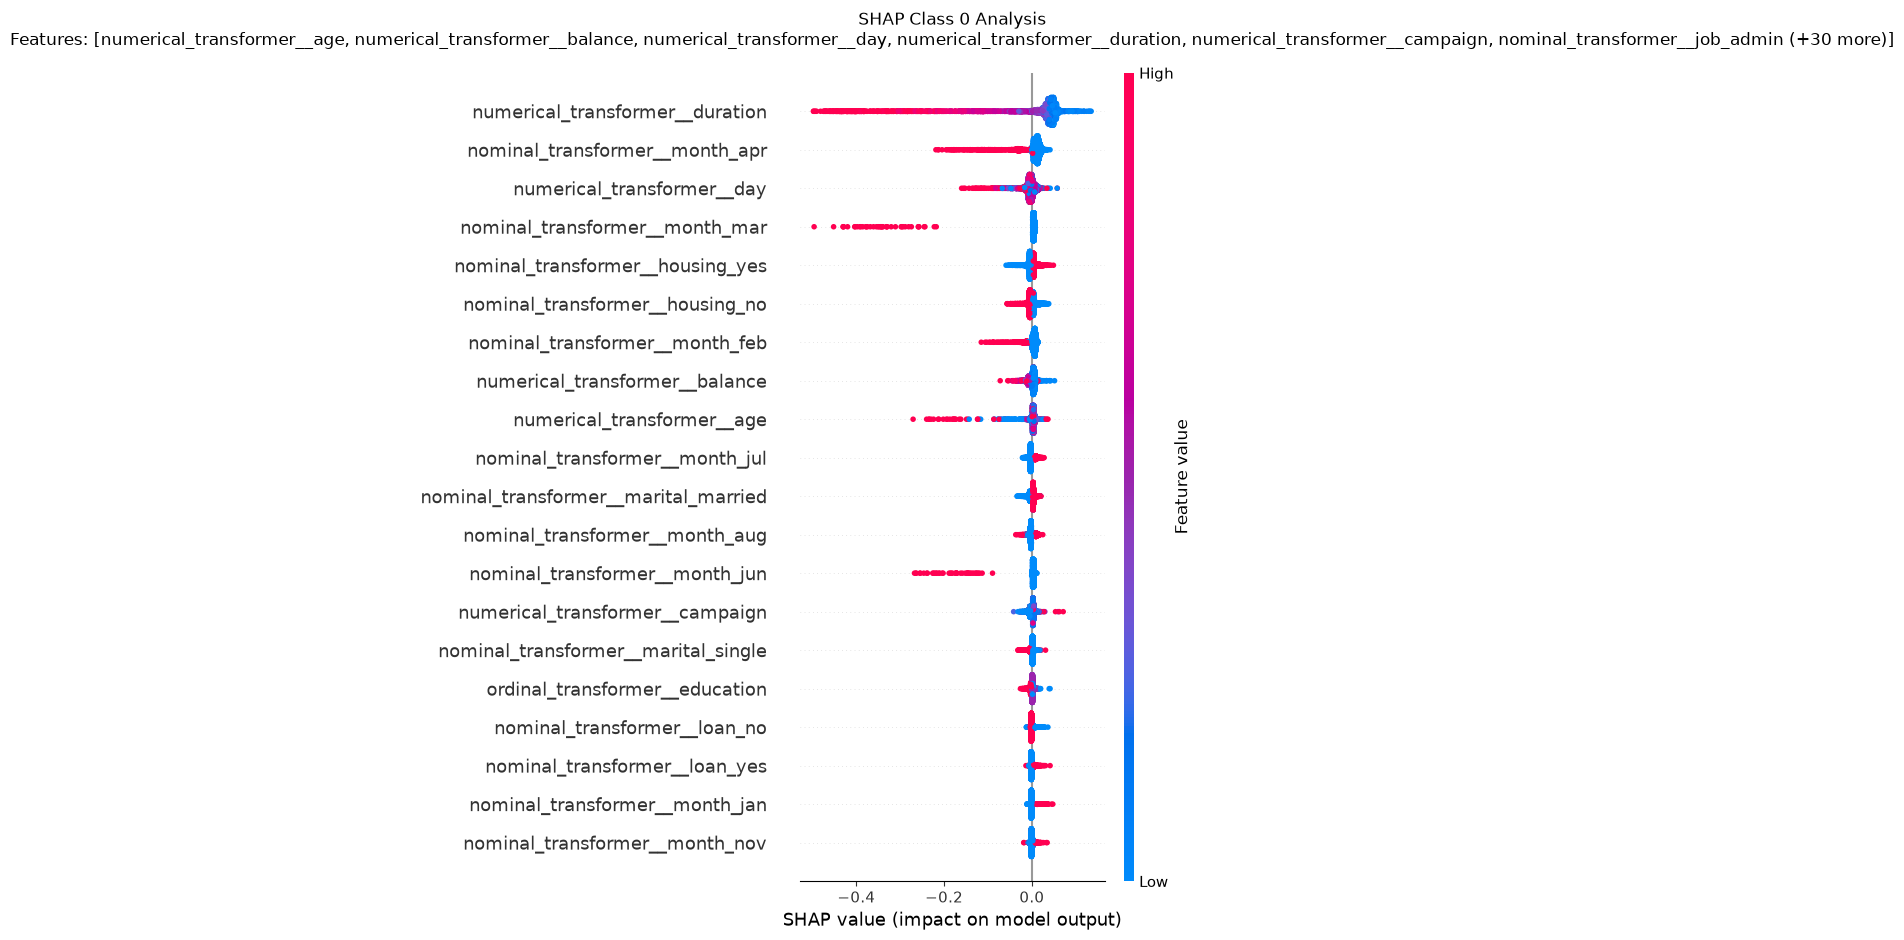

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


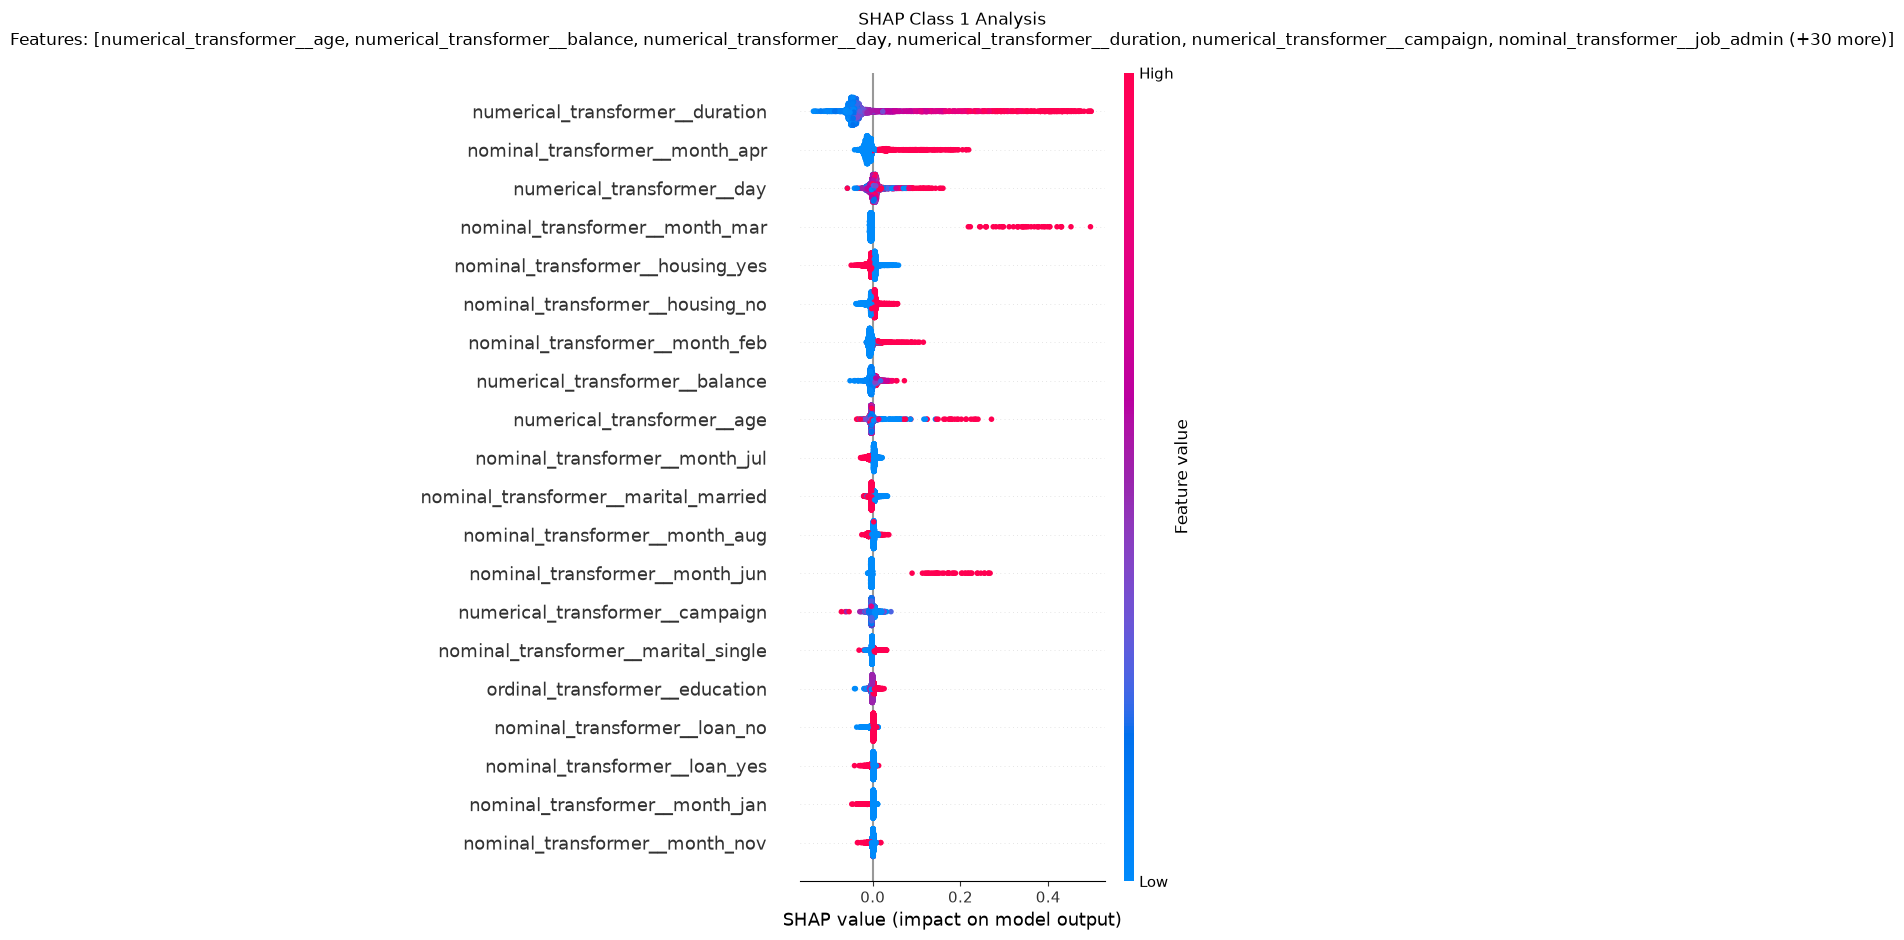

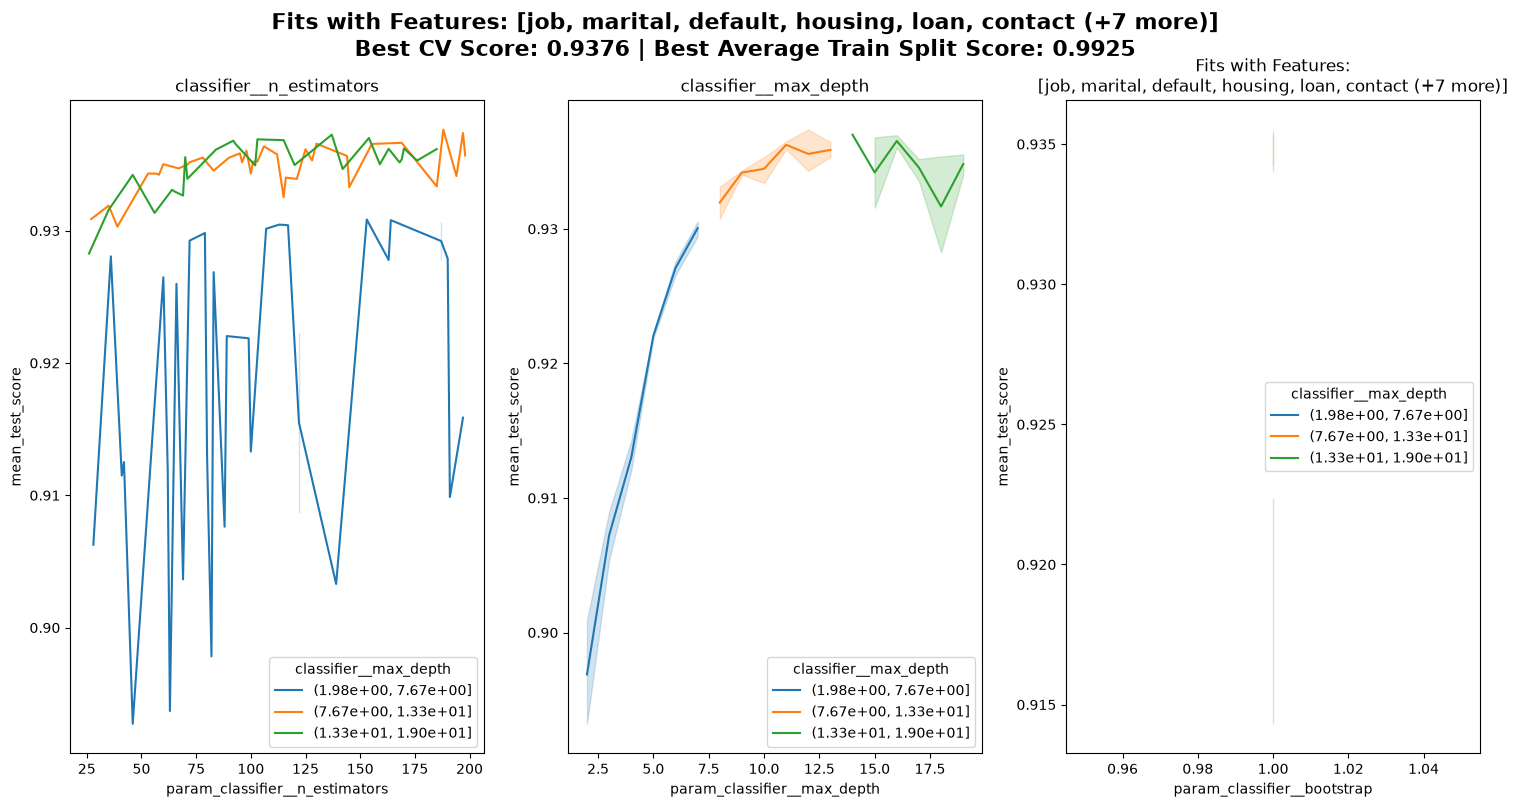

In [ ]:
filename = r"../../data/processed/no_month_outliers_no_unknown.csv"

# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education',]
education_order = ["primary", "secondary", "tertiary"]

numerical_features = ['age', 'balance','day', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    # "classifier__min_samples_split": randint(2, 21),
    # "classifier__min_samples_leaf": randint(1, 21),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t2 = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)

search2 = t2.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t2.feature_permutation(search2.best_params_, scoring = 'roc_auc')
t2.shap_analysis(search2.best_params_)
t2.display_parameter_fits(search2, parameter_grid, groupby="classifier__max_depth")

In [ ]:
t2.predict_test_split(t2.last_search.best_params_, scoring = ["roc_auc","accuracy"])

{'roc_auc': 0.9444200509811, 'accuracy': 0.9207873259721555}

# age_binned

In [ ]:
random_state += 1

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172
[CV 1/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172;, score=(train=0.979, test=0.944) total time=   1.8s
[CV 2/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172
[CV 2/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172;, score=(train=0.980, test=0.931) total time=   1.8s
[CV 3/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172
[CV 3/5; 1/100] END classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172;, score=(train=0.978, test=0.936) total time=   1.8s
[CV 4/5; 1/100] START classifier__bootstrap=True, classifier__max_depth=12, classifier__n_estimators=172
[CV 4/5; 1/100] END classifier__bootstrap=True, c

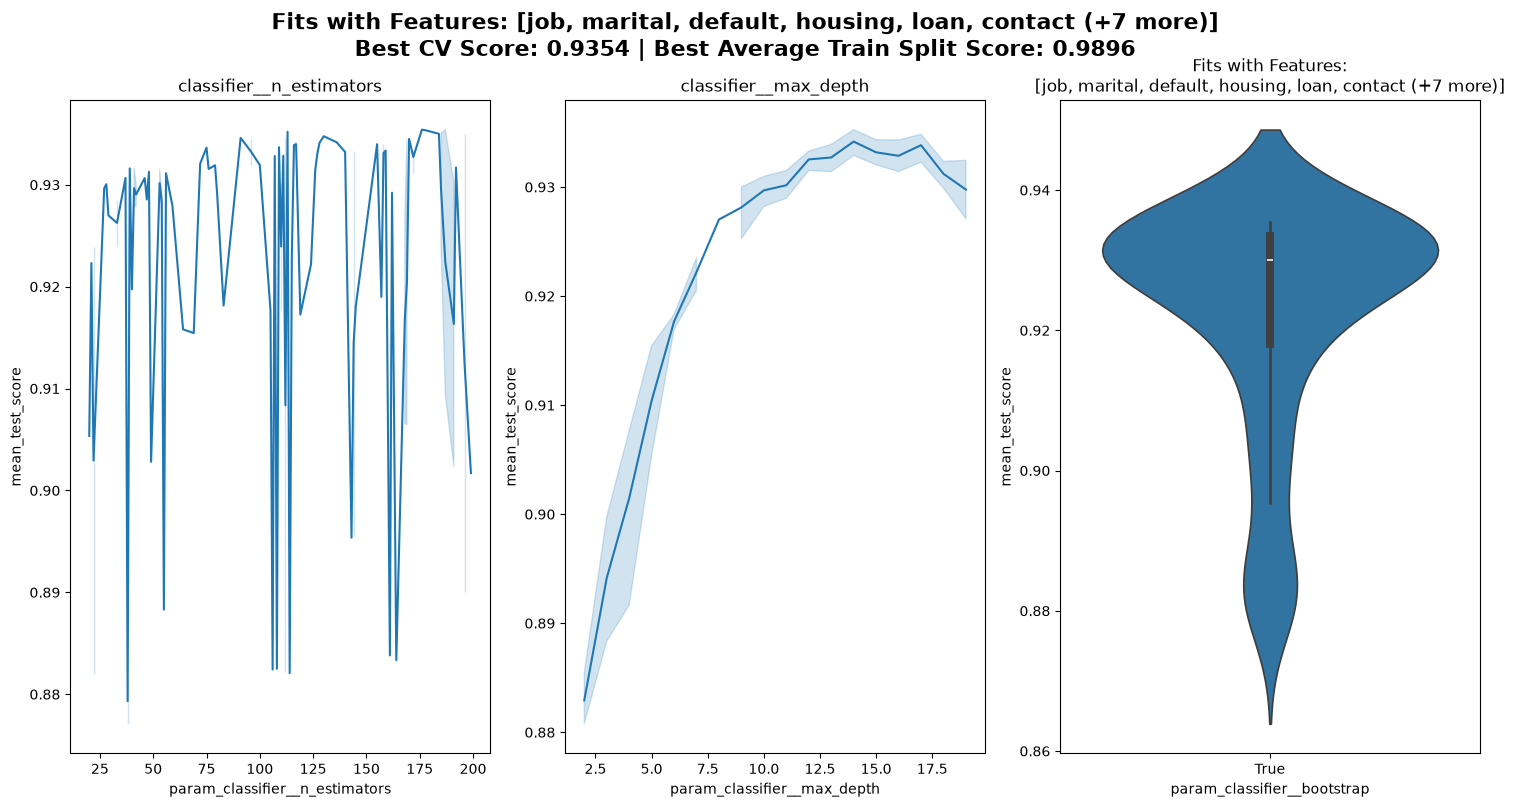



Feature Permutation Importance
______________________
duration: 0.291 +/- 0.010
month: 0.095 +/- 0.005
day: 0.019 +/- 0.002
housing: 0.013 +/- 0.002
age: 0.002 +/- 0.000
balance: 0.002 +/- 0.001
campaign: 0.001 +/- 0.001
job: 0.001 +/- 0.001
marital: 0.001 +/- 0.001
loan: 0.001 +/- 0.000
contact: 0.001 +/- 0.001
education: 0.000 +/- 0.001
default: 0.000 +/- 0.000

______________________



classifier:  RandomForestClassifier(max_depth=14, n_estimators=176, random_state=3) 





e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


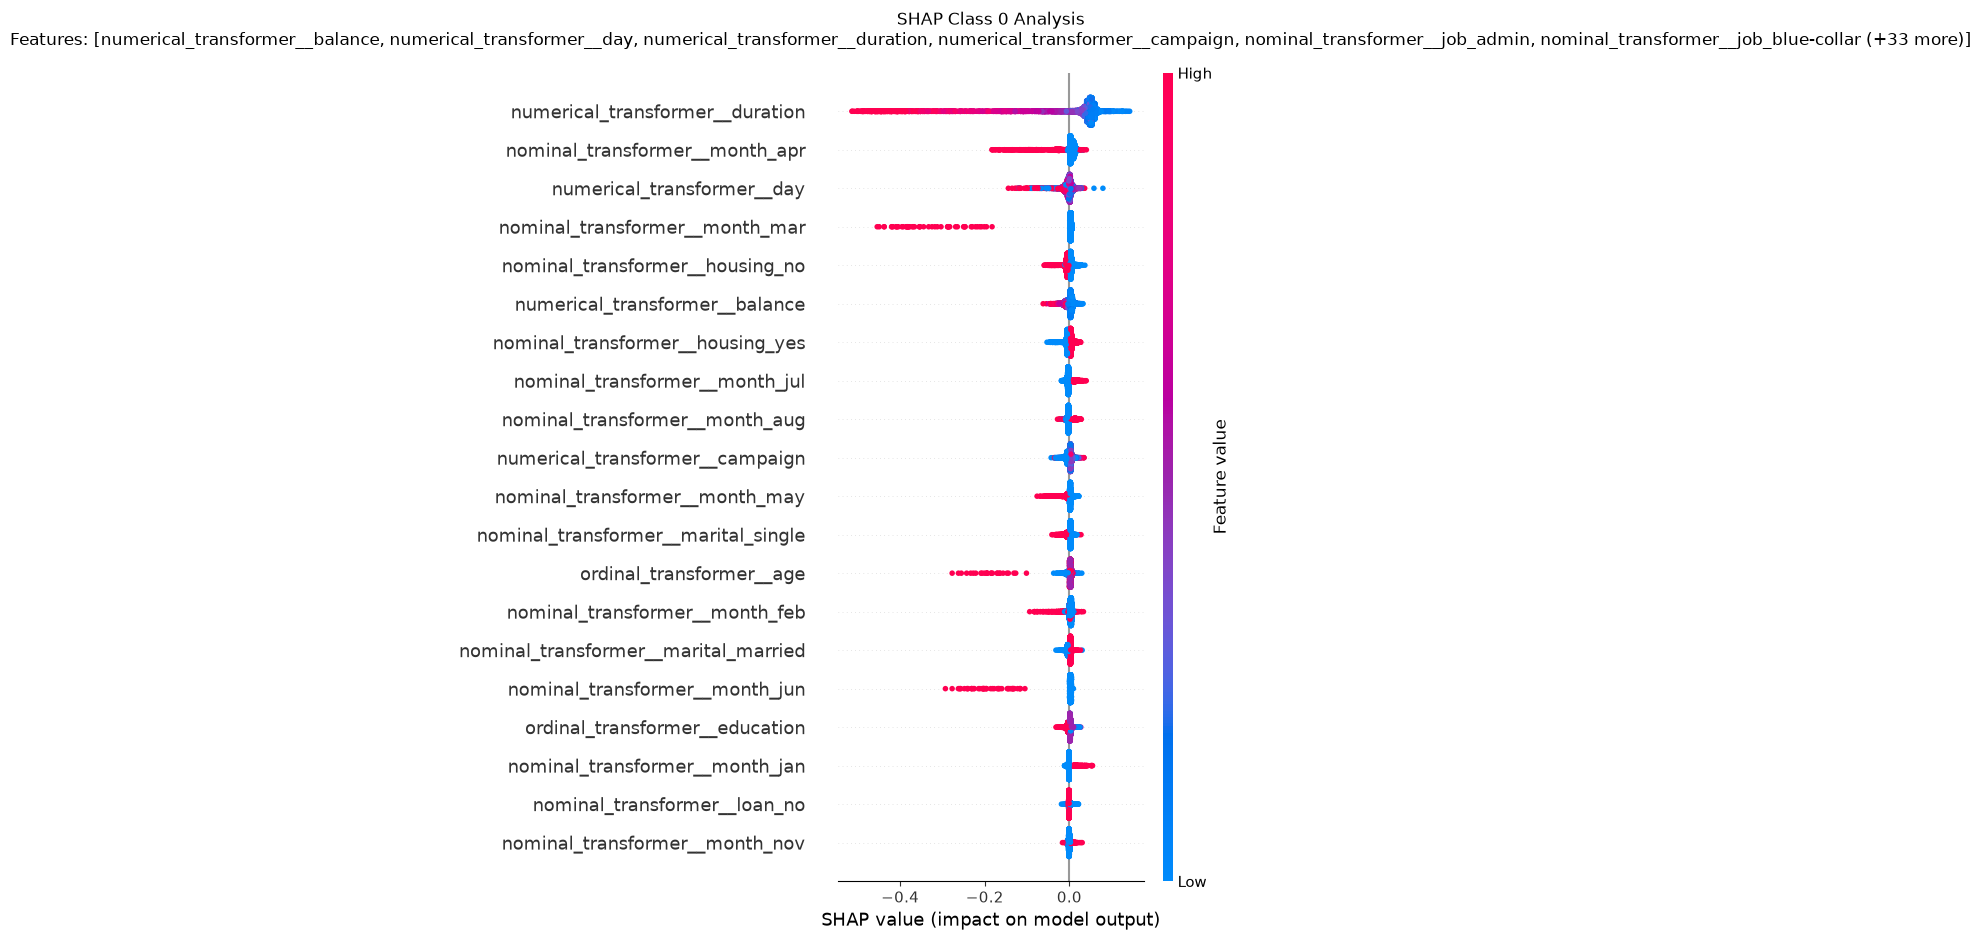

e:\dev\workspace\Apziva\Project2\src\utils\tune_hyperparameters.py:417: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.values[:, :, i], X_test_transformed_df, show=False)


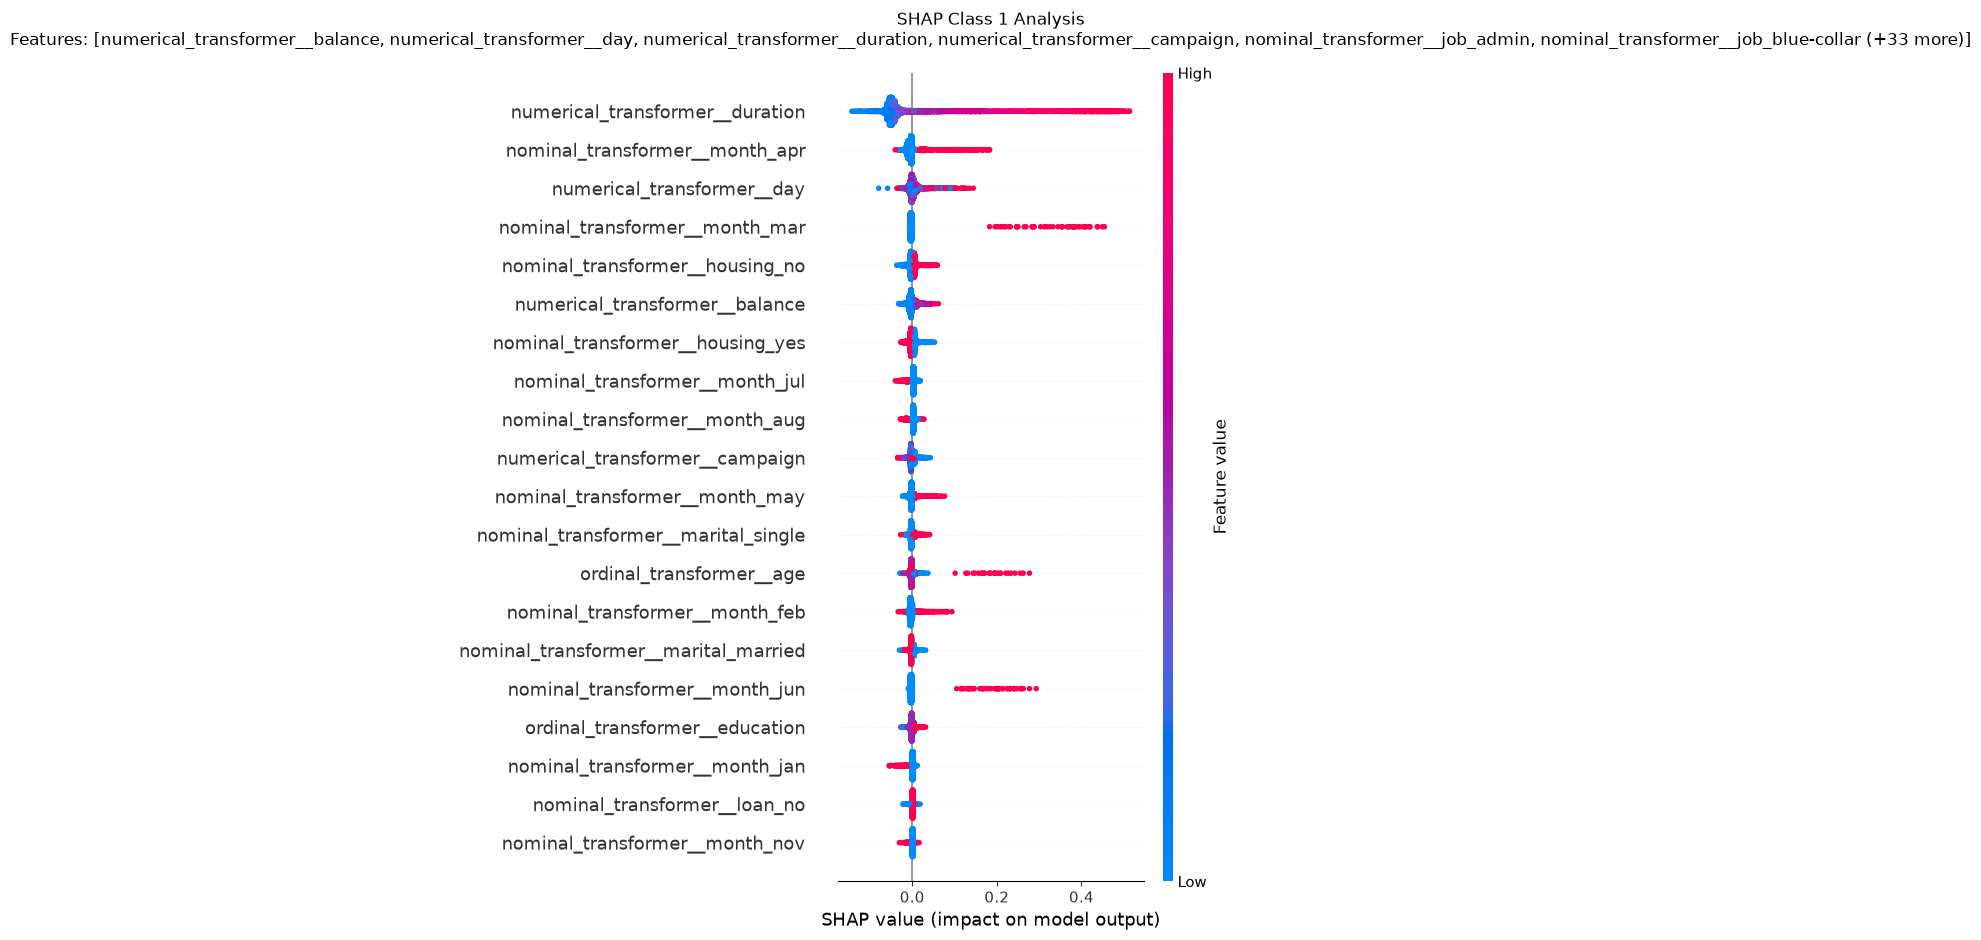

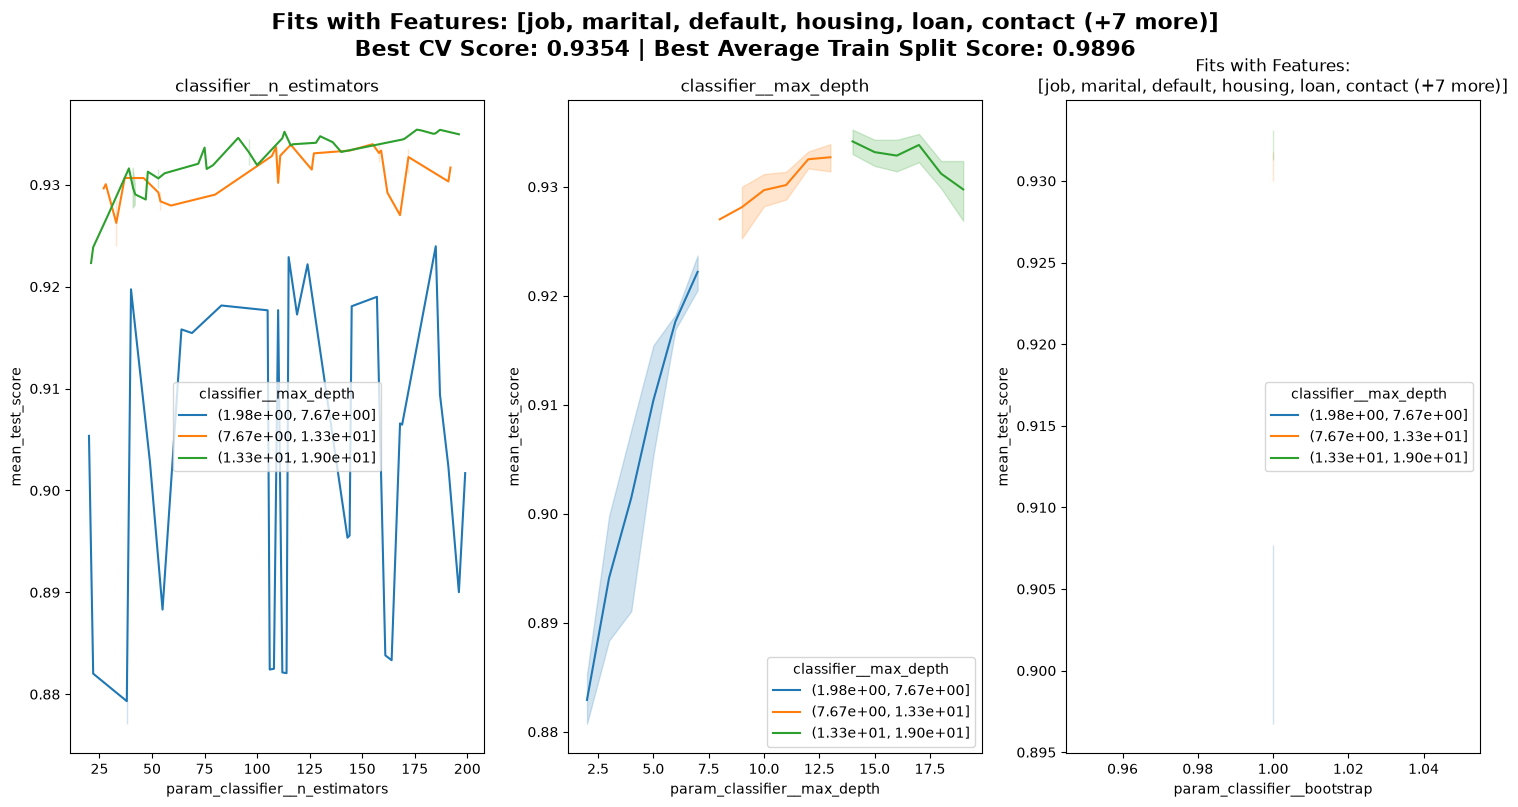

In [ ]:
filename = r"../../data/processed/binned_age.csv"

# Define your features
nominal_features = ['job', 'marital',  'default', 'housing', 'loan', 'contact', 'month',]

ordinal_features = ['education','age',]
education_order = ["primary", "secondary", "tertiary"]
age_order = [
            "gen_beta",
            "gen_alpha",
            "gen_z",
            "millennial",
            "gen_x",
            "baby_boomers",
            "silent_generation",
            "greatest_generation",
               ]

numerical_features = [ 'balance','day', 'duration', 'campaign',]

all_features = nominal_features + ordinal_features + numerical_features



# 2. Create the transformers
numerical_transformer = Pipeline(
    steps=[
        ("Numerical", StandardScaler()),  
    ]
)
nominal_transformer = Pipeline(
    steps=[
        ("NominalEncoder", OneHotEncoder()),  
    ]
)
ordinal_transformer = Pipeline(
    steps=[
        ("OrdinalEncoder", OrdinalEncoder(categories=[education_order, age_order])), 
        ("OrdinalScaler", StandardScaler()),  
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical_transformer",
            numerical_transformer,
            numerical_features,
        ),
        (
            "nominal_transformer",
            nominal_transformer,
            nominal_features,
        ),
        (
            "ordinal_transformer",
            ordinal_transformer,
            ordinal_features,
        ),
    ],
    remainder="passthrough",  # Keeps any other columns untouched
)

# 4. Final Pipeline structure containing the PCA preprocessor and your classifier
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=random_state)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": randint(20, 200),
    "classifier__max_depth": randint(2,20),
    # "classifier__min_samples_split": randint(2, 21),
    # "classifier__min_samples_leaf": randint(1, 21),
    # "classifier__max_features": ["sqrt", "log2", None],
    # "classifier__min_weight_fraction_leaf": uniform(0.0, 0.5),
    "classifier__bootstrap": [True],
}


split = get_split_from_file(filename = filename, predictor='y', random_state = random_state)
t3 = PipelineTuner(pipeline, split=split, featureNames=all_features, random_state = random_state)

search3 = t3.tune_model(hyperParameterGrid=parameter_grid, n_iter = 100, scoring = 'roc_auc')
t3.feature_permutation(search3.best_params_, scoring = 'roc_auc')
t3.shap_analysis(search3.best_params_)
t3.display_parameter_fits(search3, parameter_grid, groupby="classifier__max_depth")

In [ ]:
t3.predict_test_split(t3.last_search.best_params_, scoring = ["roc_auc","accuracy"])


{'roc_auc': 0.9405200878341743, 'accuracy': 0.9254611142802814}